In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Path to your dataset (replace this if your directory name changes)
data_dir = "D:\coronal_png_output"

# ImageNet statistics for normalization (used by pretrained ResNet18)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Define preprocessing transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ])
}

# Load datasets
image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

# Create DataLoaders
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=4)
    for x in ['train', 'val', 'test']
}

# Dataset sizes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

# Print basic info
print("✅ Datasets loaded successfully!")
print("Classes:", class_names)
print("Dataset sizes:", dataset_sizes)


✅ Datasets loaded successfully!
Classes: ['AD', 'CN', 'MCI']
Dataset sizes: {'train': 9170, 'val': 1145, 'test': 1155}


In [2]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
import numpy as np

# ============================
# Configuration Parameters
# ============================
data_dir = 'D:/coronal_png_output'  # Path to dataset directory
num_classes = 3
num_epochs = 10
batch_size = 8
k_folds = 5
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# Data Transformations
# ============================
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # In case images are single channel
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ============================
# Load Dataset from Folders
# ============================
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms)

# ============================
# K-Fold Cross Validation
# ============================
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# ============================
# Training Function
# ============================
def train_one_fold(model, criterion, optimizer, train_loader, val_loader):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

        # Validation step
        model.eval()
        val_corrects = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = val_corrects.double() / len(val_loader.dataset)
        print(f"Validation Accuracy: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, all_preds, all_labels

# ============================
# Start K-Fold Training
# ============================
fold_results = {}

for fold, (train_idx, val_idx) in enumerate(kfold.split(full_dataset)):
    print(f"\n===== Fold {fold + 1} =====")

    train_subset = Subset(full_dataset, train_idx)
    val_subset = Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Initialize ResNet18 with Transfer Learning
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train and Validate
    model, preds, labels = train_one_fold(model, criterion, optimizer, train_loader, val_loader)

    # Save classification report
    report = classification_report(labels, preds, output_dict=True)
    fold_results[f"fold_{fold+1}"] = report

    # Save model for this fold
    torch.save(model.state_dict(), f"resnet18_fold{fold+1}.pth")
    print(f"✅ Saved model for Fold {fold+1}")

# ============================
# Summary of All Folds
# ============================
print("\n📊 Cross-validation Summary:")
for fold, metrics in fold_results.items():
    acc = metrics['accuracy']
    print(f"{fold}: Accuracy = {acc:.4f}")



===== Fold 1 =====


d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10, Loss: 0.6798, Accuracy: 0.7958
Validation Accuracy: 0.8073
Epoch 2/10, Loss: 0.6655, Accuracy: 0.7975
Validation Accuracy: 0.8073
Epoch 3/10, Loss: 0.6579, Accuracy: 0.7975
Validation Accuracy: 0.8073
Epoch 4/10, Loss: 0.6610, Accuracy: 0.7970
Validation Accuracy: 0.8030
Epoch 5/10, Loss: 0.6583, Accuracy: 0.7973
Validation Accuracy: 0.8073
Epoch 6/10, Loss: 0.6539, Accuracy: 0.7975
Validation Accuracy: 0.8073
Epoch 7/10, Loss: 0.6525, Accuracy: 0.7975
Validation Accuracy: 0.8073
Epoch 8/10, Loss: 0.6505, Accuracy: 0.7975
Validation Accuracy: 0.8073
Epoch 9/10, Loss: 0.6490, Accuracy: 0.7975
Validation Accuracy: 0.8073
Epoch 10/10, Loss: 0.6499, Accuracy: 0.7975
Validation Accuracy: 0.8073
✅ Saved model for Fold 1

===== Fold 2 =====


d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch

Epoch 1/10, Loss: 0.6779, Accuracy: 0.8011
Validation Accuracy: 0.7838
Epoch 2/10, Loss: 0.6540, Accuracy: 0.8029
Validation Accuracy: 0.7838
Epoch 3/10, Loss: 0.6471, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 4/10, Loss: 0.6454, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 5/10, Loss: 0.6423, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 6/10, Loss: 0.6399, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 7/10, Loss: 0.6395, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 8/10, Loss: 0.6394, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 9/10, Loss: 0.6371, Accuracy: 0.8034
Validation Accuracy: 0.7838
Epoch 10/10, Loss: 0.6356, Accuracy: 0.8034
Validation Accuracy: 0.7838
✅ Saved model for Fold 2

===== Fold 3 =====


...

d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch

Epoch 1/10, Loss: 0.6814, Accuracy: 0.7961
Validation Accuracy: 0.8086
Epoch 2/10, Loss: 0.6612, Accuracy: 0.7966
Validation Accuracy: 0.8086
Epoch 3/10, Loss: 0.6578, Accuracy: 0.7964
Validation Accuracy: 0.8065
Epoch 4/10, Loss: 0.6596, Accuracy: 0.7963
Validation Accuracy: 0.8086
Epoch 5/10, Loss: 0.6524, Accuracy: 0.7972
Validation Accuracy: 0.8082
Epoch 6/10, Loss: 0.6499, Accuracy: 0.7971
Validation Accuracy: 0.8086
Epoch 7/10, Loss: 0.6484, Accuracy: 0.7972
Validation Accuracy: 0.8086
Epoch 8/10, Loss: 0.6454, Accuracy: 0.7970
Validation Accuracy: 0.8086
Epoch 9/10, Loss: 0.6471, Accuracy: 0.7971
Validation Accuracy: 0.8086
Epoch 10/10, Loss: 0.6433, Accuracy: 0.7972
Validation Accuracy: 0.8086
✅ Saved model for Fold 4

===== Fold 5 =====


d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch

Epoch 1/10, Loss: 0.6773, Accuracy: 0.7969
Validation Accuracy: 0.7951
Epoch 2/10, Loss: 0.6606, Accuracy: 0.8001
Validation Accuracy: 0.7951
Epoch 3/10, Loss: 0.6516, Accuracy: 0.8005
Validation Accuracy: 0.7934
Epoch 4/10, Loss: 0.6508, Accuracy: 0.8005
Validation Accuracy: 0.7951
Epoch 5/10, Loss: 0.6487, Accuracy: 0.8003
Validation Accuracy: 0.7951
Epoch 6/10, Loss: 0.6458, Accuracy: 0.8006
Validation Accuracy: 0.7568
Epoch 7/10, Loss: 0.6464, Accuracy: 0.8006
Validation Accuracy: 0.7951
Epoch 8/10, Loss: 0.6433, Accuracy: 0.8006
Validation Accuracy: 0.7951
Epoch 9/10, Loss: 0.6421, Accuracy: 0.8006
Validation Accuracy: 0.7951
Epoch 10/10, Loss: 0.6430, Accuracy: 0.8006
Validation Accuracy: 0.7951
✅ Saved model for Fold 5

📊 Cross-validation Summary:
fold_1: Accuracy = 0.8073
fold_2: Accuracy = 0.7838
fold_3: Accuracy = 0.8025
fold_4: Accuracy = 0.8086
fold_5: Accuracy = 0.7951


d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
#deep feature extraction code
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import pandas as pd
from tqdm import tqdm

# ========= Configurations ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_folder = 'D:\coronal_png_output'  # This folder contains train, val, test folders
output_csv = 'resnet18_features_all.csv'
batch_size = 6
# ===================================

# ========= Custom Dataset ==========
class FeatureDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.filenames = []
        self.class_map = {'AD': 0, 'CN': 1, 'MCI': 2}
        self.transform = transform

        for split in ['train', 'val', 'test']:
            for cls in os.listdir(os.path.join(root_dir, split)):
                cls_path = os.path.join(root_dir, split, cls)
                if os.path.isdir(cls_path):
                    for img_file in os.listdir(cls_path):
                        self.image_paths.append(os.path.join(cls_path, img_file))
                        self.labels.append(cls)
                        self.filenames.append(img_file)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label, self.filenames[idx]

# ========= Image Preprocessing ==========
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet means
        std=[0.229, 0.224, 0.225]    # ImageNet stds
    )
])

# ========= Load Dataset ==========
dataset = FeatureDataset(image_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# ========= Load Fine-Tuned ResNet18 ==========
# NOTE: Replace this with your saved model path
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 3)  # Assuming 3 classes
model.load_state_dict(torch.load("D:/resnet18_fold1.pth", map_location=device))  # 🔁 Your model here
model = model.to(device)
model.eval()

# ========= Modify to Extract Features ==========
# We remove the classification head and keep up to avgpool
feature_extractor = nn.Sequential(*list(model.children())[:-1])  # Removes final FC
feature_extractor.to(device)
feature_extractor.eval()

# ========= Extract Features ==========
all_features = []
all_labels = []
all_filenames = []

with torch.no_grad():
    for imgs, labels, filenames in tqdm(dataloader, desc="Extracting features"):
        imgs = imgs.to(device)
        feats = feature_extractor(imgs)  # Output: (batch_size, 512, 1, 1)
        feats = feats.view(feats.size(0), -1)  # Flatten to (batch_size, 512)

        all_features.extend(feats.cpu().numpy())
        all_labels.extend(labels)
        all_filenames.extend(filenames)

# ========= Save to CSV ==========
df = pd.DataFrame(all_features, columns=[f"feat_{i}" for i in range(512)])
df['label'] = all_labels
df['filename'] = all_filenames
df.to_csv(output_csv, index=False)
print(f"✅ Feature CSV saved: {output_csv}")


d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\Nimra Nadeem\AppData\Local\Temp\ipykernel_424\4175960019.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will

✅ Feature CSV saved: resnet18_features_all.csv


In [22]:
# feature selection code
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# === Load Features ===
df = pd.read_csv('resnet18_features_all.csv')

# Separate features and labels
X = df.drop(columns=['filename', 'label']).values  # shape: (samples, 512)
y = df['label'].values                             # shape: (samples,)

# === Feature Normalization (optional but helpful) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Feature Selection: SelectKBest ===
k = 1000  # Select top 100 features; try k=50, 128, etc.
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_scaled, y)

# Get selected feature indices
selected_indices = selector.get_support(indices=True)
print(f"Selected top {k} features: {selected_indices}")

# === Create new DataFrame with selected features ===
selected_feature_names = [f"feat_{i}" for i in selected_indices]
df_selected = pd.DataFrame(X_selected, columns=selected_feature_names)
df_selected['label'] = y
df_selected['filename'] = df['filename']

# Save the selected features for fusion/classification
df_selected.to_csv(f"resnet18_features_selected_top{k}.csv", index=False)
print(f"✅ Selected features saved to: resnet18_features_selected_top{k}.csv")


d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=1000 is greater than n_features=512. All the features will be returned.
  warnings.warn(


Selected top 1000 features: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 23

d:\Anaconda\envs\torch_gpu\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Anaconda\envs\torch_gpu\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


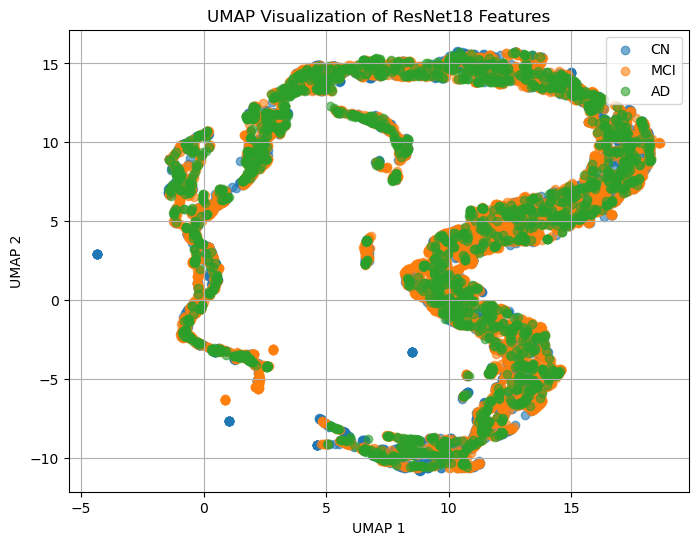

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

# ========== Step 1: Load Selected Feature CSV ==========
csv_path = "resnet18_features_selected_top1000.csv"
df = pd.read_csv(csv_path)

# ========== Step 2: Extract Features and Labels ==========
features = df.drop(['filename', 'label'], axis=1)
labels = df['label']  # Already contains 'CN', 'MCI', 'AD'

# ========== Step 3: Normalize the Feature Data ==========
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# ========== Step 4: Apply UMAP ==========
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
umap_result = umap_model.fit_transform(features_scaled)

# ========== Step 5: Plot the UMAP Output ==========
plt.figure(figsize=(8, 6))
for class_name in ['CN', 'MCI', 'AD']:
    idx = labels == class_name
    plt.scatter(umap_result[idx, 0], umap_result[idx, 1], label=class_name, alpha=0.6)
plt.title("UMAP Visualization of ResNet18 Features")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()
